In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('train.txt',sep=';',header=None,names=['text','emotion'])

In [3]:
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [4]:
df.isnull().sum()

text       0
emotion    0
dtype: int64

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['emotion'] = le.fit_transform(df['emotion'])

In [6]:
df

,text,emotion
0,i didnt feel humiliated,4
1,i can go from feeling so hopeless to so damned...,4
2,im grabbing a minute to post i feel greedy wrong,0
3,i am ever feeling nostalgic about the fireplac...,3
4,i am feeling grouchy,0
...,...,...
15995,i just had a very brief time in the beanbag an...,4
15996,i am now turning and i feel pathetic that i am...,4
15997,i feel strong and good overall,2
15998,i feel like this was such a rude comment and i...,0


In [7]:
def to_lower(txt):
    return txt.lower()

df['text']=df['text'].apply(to_lower)

In [8]:
def remove_numbers(txt):
    new = ''
    for i in txt:
        if not i.isdigit():
            new += i
    return new

df['text']=df['text'].apply(remove_numbers)

In [9]:
def remove_emojis(txt):
    new = ''
    for i in txt:
        if i.isascii():
            new += i
    return new

df['text']=df['text'].apply(remove_emojis)

In [10]:
import string

def remove_punc(txt):
    return txt.translate(str.maketrans('', '', string.punctuation))

df['text'] = df['text'].apply(remove_punc)

In [11]:
def remove_extra_spaces(txt):
    return " ".join(txt.split())

df['text']=df['text'].apply(remove_extra_spaces)

In [12]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
print(stop_words)

{'your', 'doesn', 'themselves', 'more', 'being', 'his', 'each', 't', 'its', 'y', 'ours', 'most', 'at', 'we', 'from', 'll', "that'll", "we're", 'while', 'myself', "hasn't", 'yourselves', "didn't", 'it', 'over', 'during', 'mightn', 'above', 'than', 'mustn', 'him', 'then', "it'll", "we've", 'how', 'where', "couldn't", 'have', 'here', 'such', 'should', 'our', "you'll", 'a', 'just', 'and', "she'd", 'until', 'these', 'been', 'be', 'was', 'all', 'both', 'the', 'their', 'o', "she'll", 'what', 'too', "you've", 'shouldn', "i'll", "he'll", 'she', 'through', 'before', "we'd", 'they', 'wasn', 'wouldn', 'theirs', 'between', 'weren', 'having', 'an', 'does', 'when', 'had', 're', 'herself', 'few', 'further', 'of', 'not', 'her', "i'm", 'once', "you'd", "you're", 'has', 'aren', 'can', 'some', 'own', 'that', 'did', 'them', 'other', 's', 'now', 'under', 'again', 'as', 'by', 'if', "should've", 'this', "wasn't", 'who', 'any', 'up', "won't", 'i', "it'd", 'didn', "isn't", 'those', 'yourself', 'isn', "haven't",

In [13]:
len(stop_words)

198

In [14]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(txt):
    words = txt.split()
    cleaned = []
    
    for word in words:
        if word not in stop_words:
            cleaned.append(word)
    
    return " ".join(cleaned)

df['text']=df['text'].apply(remove_stopwords)

In [15]:
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(txt):
    words = word_tokenize(txt)
    new = []
    
    for word in words:
        new.append(lemmatizer.lemmatize(word))
    
    return " ".join(new)

df['text'] = df['text'].apply(lemmatize_text)

In [16]:
df.loc[1]['text']

'go feeling hopeless damned hopeful around someone care awake'

In [17]:
df.head()

,text,emotion
0,didnt feel humiliated,4
1,go feeling hopeless damned hopeful around some...,4
2,im grabbing minute post feel greedy wrong,0
3,ever feeling nostalgic fireplace know still pr...,3
4,feeling grouchy,0


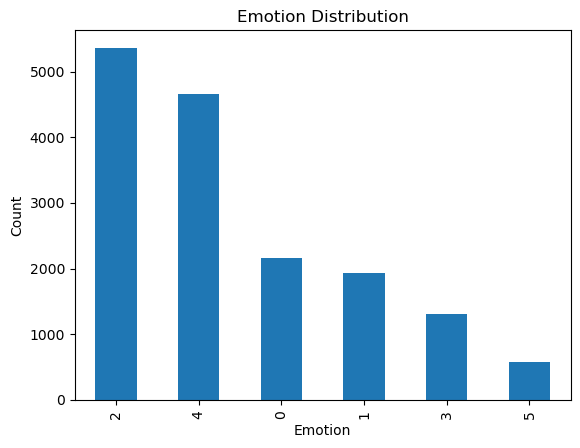

In [18]:
target_col = 'emotion'

df[target_col].value_counts().plot(kind='bar')
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

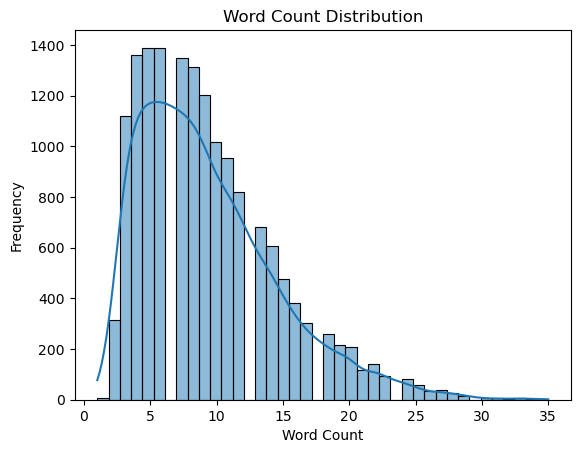

In [19]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
sns.histplot(df['word_count'], bins=40, kde=True)
plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

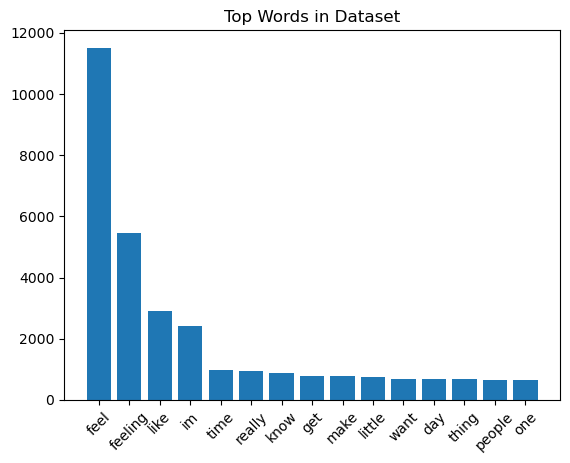

In [20]:
from collections import Counter

all_words = []
for txt in df['text']:
    for word in txt.split():
        all_words.append(word)

common_words = Counter(all_words).most_common(15)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Words in Dataset")
plt.show()

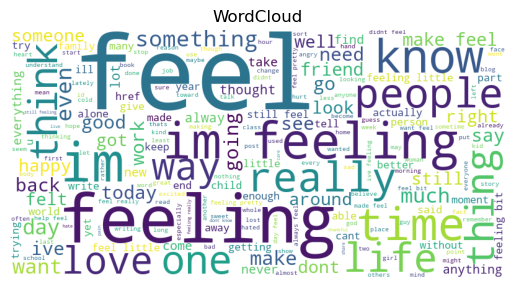

In [21]:
from wordcloud import WordCloud

text = ""
for t in df['text']:
    text += t + " "

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc.to_image())   
plt.axis('off')
plt.title("WordCloud")
plt.show()

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['text'],df['emotion'], 
                test_size=0.20, random_state=42)

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer

In [24]:
bow_vectorizer = CountVectorizer(
    max_features=15000,    
    ngram_range=(1,1),      
    min_df=3,               
    max_df=0.85             
)

In [25]:
X_train_bow=bow_vectorizer.fit_transform(X_train)
X_test_bow=bow_vectorizer.transform(X_test)

In [26]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=12000,      
    ngram_range=(1,1),       
    min_df=3,                
    max_df=0.85,            
    sublinear_tf=True        
)

In [27]:
X_train_tfidf=tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf=tfidf_vectorizer.transform(X_test)

In [28]:
from sklearn.naive_bayes import  MultinomialNB
from sklearn.metrics import accuracy_score

In [29]:
nb_model=MultinomialNB()

In [30]:
nb_model.fit(X_train_bow,y_train)

MultinomialNB()

In [31]:
pred_bow=nb_model.predict(X_test_bow)
print(accuracy_score(y_test,pred_bow))

0.8390625


In [32]:
nb2_model=MultinomialNB()

In [33]:
nb2_model.fit(X_train_tfidf,y_train)

MultinomialNB()

In [34]:
pred_tfidf=nb2_model.predict(X_test_tfidf)
print(accuracy_score(y_test,pred_tfidf))

0.7390625


In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:
logistic_model = LogisticRegression(
    C=0.45,
    max_iter=1000,
    class_weight='balanced'
)

In [37]:
logistic_model.fit(X_train_tfidf,y_train)

LogisticRegression(C=0.45, class_weight='balanced', max_iter=1000)

In [38]:
train_pred = logistic_model.predict(X_train_tfidf)
test_pred = logistic_model.predict(X_test_tfidf)

In [39]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

In [40]:

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.918515625
Test Accuracy: 0.8815625


In [41]:
import joblib
joblib.dump(le, "label_encoder.pkl")
joblib.dump(logistic_model, "model.pkl")
joblib.dump(tfidf_vectorizer, "vectorizer.pkl")

['vectorizer.pkl']